# WFH Burnout — 02: Models & Feature Importance

Trains three classifiers and extracts feature importance using three different methods to build a consensus ranking of the most important burnout predictors.

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.inspection import permutation_importance

sns.set_theme(style='whitegrid', font_scale=1.1)
PALETTE = {'Low': '#4CAF50', 'Medium': '#FF9800', 'High': '#F44336'}
ORDER   = ['Low', 'Medium', 'High']
BEHAVIORAL = [
    'work_hours', 'screen_time_hours', 'meetings_count', 'breaks_taken',
    'after_hours_work', 'app_switches', 'sleep_hours', 'task_completion',
    'isolation_index'
]
print('Libraries loaded')

Libraries loaded


In [2]:
# Load data and encode categorical feature
# day_type encoded as binary: Weekday=1, Weekend=0
CSV_PATH = 'wfh_burnout_dataset.csv'
df = pd.read_csv(CSV_PATH)
df.drop(columns=['user_id'], inplace=True)
df['day_type_enc'] = (df['day_type'] == 'Weekday').astype(int)

FEATURES = BEHAVIORAL + ['day_type_enc']
X = df[FEATURES]
y = df['burnout_risk']

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (2000, 10)
y shape: (2000,)


In [3]:
# Stratified 80/20 train-test split
# Stratify ensures the same class proportions appear in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print('\nTrain class distribution:')
print((y_train.value_counts() / len(y_train) * 100).round(1))
print('\nTest class distribution:')
print((y_test.value_counts() / len(y_test) * 100).round(1))

Train: (1600, 10), Test: (400, 10)

Train class distribution:
burnout_risk
Low       50.9
Medium    42.1
High       6.9
Name: count, dtype: float64

Test class distribution:
burnout_risk
Low       51.0
Medium    42.2
High       6.8
Name: count, dtype: float64


In [4]:
# Feature scaling — StandardScaler transforms each feature to mean=0, std=1
# Scaler is fit only on training data to prevent test-set leakage
scaler         = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURES)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=FEATURES)
print('Scaling complete')
print('Mean of scaled train features (should all be ~0):')
print(X_train_scaled.mean().round(3).to_string())

Scaling complete
Mean of scaled train features (should all be ~0):
work_hours          -0.0
screen_time_hours   -0.0
meetings_count      -0.0
breaks_taken         0.0
after_hours_work     0.0
app_switches        -0.0
sleep_hours         -0.0
task_completion      0.0
isolation_index      0.0
day_type_enc         0.0


In [5]:
# Logistic Regression
# Feature importance: mean absolute standardized coefficient across classes
# class_weight='balanced' upweights the minority High class during training
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

print('=== Logistic Regression — Classification Report ===')
print(classification_report(y_test, y_pred_lr))

lr_importance = pd.Series(
    np.abs(lr_model.coef_).mean(axis=0), index=FEATURES
).sort_values(ascending=False)
print('LR Feature Importance (standardized |coef|):')
print(lr_importance.round(4).to_string())

=== Logistic Regression — Classification Report ===
              precision    recall  f1-score   support

        High       0.75      1.00      0.86        27
         Low       0.95      0.91      0.93       204
      Medium       0.89      0.89      0.89       169

    accuracy                           0.91       400
   macro avg       0.86      0.93      0.89       400
weighted avg       0.91      0.91      0.91       400

LR Feature Importance (standardized |coef|):
isolation_index      3.1425
sleep_hours          2.3799
work_hours           1.1142
screen_time_hours    0.9424
meetings_count       0.3680
after_hours_work     0.3626
app_switches         0.2752
breaks_taken         0.1343
task_completion      0.1315
day_type_enc         0.0114


In [6]:
# Random Forest
# Feature importance: Gini impurity reduction — captures non-linear relationships
rf_model = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print('=== Random Forest — Classification Report ===')
print(classification_report(y_test, y_pred_rf))

rf_importance = pd.Series(
    rf_model.feature_importances_, index=FEATURES
).sort_values(ascending=False)
print('RF Feature Importance (Gini):')
print(rf_importance.round(4).to_string())

=== Random Forest — Classification Report ===
              precision    recall  f1-score   support

        High       0.84      0.78      0.81        27
         Low       0.95      0.92      0.94       204
      Medium       0.87      0.92      0.90       169

    accuracy                           0.91       400
   macro avg       0.89      0.87      0.88       400
weighted avg       0.91      0.91      0.91       400

RF Feature Importance (Gini):
isolation_index      0.2441
sleep_hours          0.2302
work_hours           0.1904
screen_time_hours    0.1598
app_switches         0.0568
meetings_count       0.0481
task_completion      0.0430
breaks_taken         0.0164
after_hours_work     0.0062
day_type_enc         0.0048


In [7]:
# SVM (RBF kernel)
# Feature importance: permutation importance — shuffles each feature and measures AUC drop
# Used because SVM with RBF kernel has no native feature attribution method
svm_model = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

print('=== SVM — Classification Report ===')
print(classification_report(y_test, y_pred_svm))

print('Computing permutation importance (1-2 min)...')
perm = permutation_importance(svm_model, X_test_scaled, y_test, n_repeats=20, random_state=42)
svm_importance = pd.Series(perm.importances_mean, index=FEATURES).sort_values(ascending=False)
print('SVM Feature Importance (Permutation):')
print(svm_importance.round(4).to_string())

=== SVM — Classification Report ===
              precision    recall  f1-score   support

        High       0.64      1.00      0.78        27
         Low       0.97      0.92      0.95       204
      Medium       0.90      0.88      0.89       169

    accuracy                           0.91       400
   macro avg       0.84      0.93      0.87       400
weighted avg       0.92      0.91      0.91       400

Computing permutation importance (1-2 min)...
SVM Feature Importance (Permutation):
isolation_index      0.2246
sleep_hours          0.1741
work_hours           0.0436
app_switches         0.0293
screen_time_hours    0.0269
meetings_count       0.0119
breaks_taken         0.0020
day_type_enc         0.0014
task_completion     -0.0050
after_hours_work    -0.0095


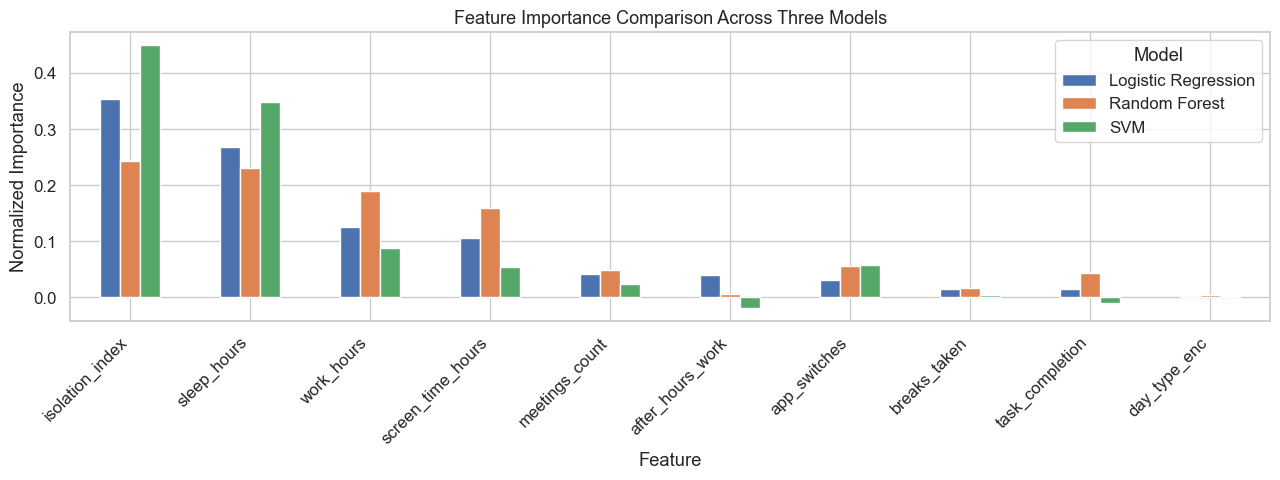

Feature Rank Comparison (1 = most important):


,LR Rank,RF Rank,SVM Rank,Mean Rank
isolation_index,1,1,1,1.0
sleep_hours,2,2,2,2.0
work_hours,3,3,3,3.0
screen_time_hours,4,4,5,4.3
app_switches,7,5,4,5.3
meetings_count,5,6,6,5.7
breaks_taken,8,8,7,7.7
after_hours_work,6,9,10,8.3
task_completion,9,7,9,8.3
day_type_enc,10,10,8,9.3


In [8]:
# Consensus feature ranking — average rank across all three models
# Lower mean rank = more consistently important across methods
def normalize(s):
    return s / s.sum()

importance_df = pd.DataFrame({
    'Logistic Regression': normalize(lr_importance),
    'Random Forest'      : normalize(rf_importance),
    'SVM'                : normalize(svm_importance)
}).reindex(lr_importance.index)

fig, ax = plt.subplots(figsize=(13, 5))
importance_df.plot(kind='bar', ax=ax)
ax.set_title('Feature Importance Comparison Across Three Models', fontsize=13)
ax.set_xlabel('Feature')
ax.set_ylabel('Normalized Importance')
ax.legend(title='Model')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('fig_07_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

rank_df = pd.DataFrame({
    'LR Rank' : lr_importance.rank(ascending=False).astype(int),
    'RF Rank' : rf_importance.rank(ascending=False).astype(int),
    'SVM Rank': svm_importance.rank(ascending=False).astype(int),
})
rank_df['Mean Rank'] = rank_df.mean(axis=1).round(1)
rank_df = rank_df.sort_values('Mean Rank')
print('Feature Rank Comparison (1 = most important):')
display(rank_df)

In [9]:
# ROC-AUC for each model
lr_auc  = roc_auc_score(y_test, lr_model.predict_proba(X_test_scaled),  multi_class='ovr')
rf_auc  = roc_auc_score(y_test, rf_model.predict_proba(X_test),         multi_class='ovr')
svm_auc = roc_auc_score(y_test, svm_model.predict_proba(X_test_scaled), multi_class='ovr')

print('='*50)
print('MODEL PERFORMANCE SUMMARY')
print('='*50)
print(f'{"Model":<25} {"ROC-AUC"}')
print('-'*50)
print(f'{"Logistic Regression":<25} {lr_auc:.4f}')
print(f'{"Random Forest":<25} {rf_auc:.4f}')
print(f'{"SVM":<25} {svm_auc:.4f}')
print('='*50)

MODEL PERFORMANCE SUMMARY
Model                     ROC-AUC
--------------------------------------------------
Logistic Regression       0.9842
Random Forest             0.9833
SVM                       0.9886


In [10]:
# Save importance scores to CSV for use in notebook 03
lr_importance.to_csv('lr_importance.csv',   header=['importance'])
rf_importance.to_csv('rf_importance.csv',   header=['importance'])
svm_importance.to_csv('svm_importance.csv', header=['importance'])
rank_df.to_csv('rank_comparison.csv')
print('Importance scores saved')
print(f'Top feature (LR) : {lr_importance.index[0]}')
print(f'Top feature (RF) : {rf_importance.index[0]}')
print(f'Top feature (SVM): {svm_importance.index[0]}')
print(f'Top consensus    : {rank_df.index[0]}')

Importance scores saved
Top feature (LR) : isolation_index
Top feature (RF) : isolation_index
Top feature (SVM): isolation_index
Top consensus    : isolation_index
